In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import numpy as np
from numpy import sin, cos, pi
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_absolute_percentage_error as mape

In [2]:
def analytical(theta:float,beta:float,alpha:float):
    return (\
        cos(alpha)**4 + sin(alpha)**4 +\
        2 * (sin(alpha)**2) * (cos(alpha)**2) * cos(theta) + \
        cos(alpha+beta)**4 + sin(alpha+beta)**4 + \
        2 * (sin(alpha+beta)**2) * (cos(alpha+beta)**2) * cos(theta)\
        )/2

In [3]:
def plot_surface_from_csv(array1,array2):
        fig = go.Figure()
        fig.add_trace(go.Surface(
            z=array1, 
            colorscale='Emrld',
            opacity=.95,
            name='Model',
            colorbar=dict(title='Theoretical', x=0.9)
        ))
        
    
        fig.add_trace(go.Surface(
            z=array2, 
            colorscale='Reds',
            opacity=0.7, # Transparency helps see where they intersect
            name='Experimental',
            colorbar=dict(title='Experimental', x=1.05)
        ))
        # Customize the layout for better visualization
        fig.update_layout(
            title='3D Surface Plot from CSV',
            autosize=False,
            width=800,
            height=800,
            margin=dict(l=65, r=50, b=65, t=90),
            scene=dict(
                xaxis_title='X Axis',
                yaxis_title='Y Axis',
                zaxis_title='Z Axis'
            )
        )
        
        # Display the plot
        fig.show()


In [4]:
reviewed_probability_filenames = pd.read_csv("./runs/filenames.csv",header=None).dropna(axis=1,how='all').values.flatten()
reviewed_probability_filenames

array(['0_E91_data_20x20_mesh_1.0E+03_states_AER_SIM_14_03_2026_16_27_06.csv',
       '1_E91_data_20x20_mesh_5.0E+03_states_AER_SIM_14_03_2026_16_35_48.csv',
       '2_E91_data_20x20_mesh_1.0E+04_states_AER_SIM_14_03_2026_17_17_08.csv',
       '3_E91_data_20x20_mesh_1.5E+04_states_AER_SIM_14_03_2026_18_45_25.csv',
       '4_E91_data_20x20_mesh_2.0E+04_states_AER_SIM_14_03_2026_21_03_06.csv',
       '5_E91_data_20x20_mesh_2.5E+04_states_AER_SIM_14_03_2026_16_28_11.csv',
       '6_E91_data_20x20_mesh_3.0E+04_states_AER_SIM_15_03_2026_05_29_40.csv',
       '7_E91_data_20x20_mesh_3.5E+04_states_AER_SIM_15_03_2026_21_10_06.csv',
       '8_E91_data_20x20_mesh_4.0E+04_states_AER_SIM_16_03_2026_15_27_57.csv',
       '9_E91_data_20x20_mesh_4.5E+04_states_AER_SIM_17_03_2026_12_20_26.csv'],
      dtype=object)

In [16]:
N_data=20

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

path = './runs/'
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

correlation_reviewed = list()
mean_absolute_error = list()
mean_absolute_percentage_error = list()

for experiment_name in reviewed_probability_filenames:
    experiment = pd.read_csv(path+experiment_name, header=None).dropna(axis=1,how='all').values    
    model_10_error = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
    correlation_reviewed.append( 1-r2(y_true=model_10_error,y_pred=experiment) )
    mean_absolute_error.append( mae(y_true=model_10_error,y_pred=experiment) )
    mean_absolute_percentage_error.append( mape(y_true=model_10_error,y_pred=experiment) )
df_reviewed = pd.DataFrame( dict(zip(['N_states','R2','MAE','MAPE'],[['1.0E3','5.0E3','1.0E4','1.5E4','2.0E4','2.5E4','3.0E4','3.5E4','4.0E4','4.5E4'],correlation_reviewed,mean_absolute_error,mean_absolute_percentage_error])) )

In [17]:
df_reviewed

,N_states,R2,MAE,MAPE
0,1.0E3,0.082469,0.017884,0.026147
1,5.0E3,0.015119,0.008965,0.013281
2,1.0E4,0.006576,0.004425,0.005956
3,1.5E4,0.005322,0.004460,0.006410
4,2.0E4,0.003639,0.003160,0.004248
5,2.5E4,0.002705,0.003649,0.005324
6,3.0E4,0.002699,0.003107,0.004367
7,3.5E4,0.002918,0.003495,0.005083
8,4.0E4,0.002343,0.003265,0.004770
9,4.5E4,0.001652,0.002548,0.003565


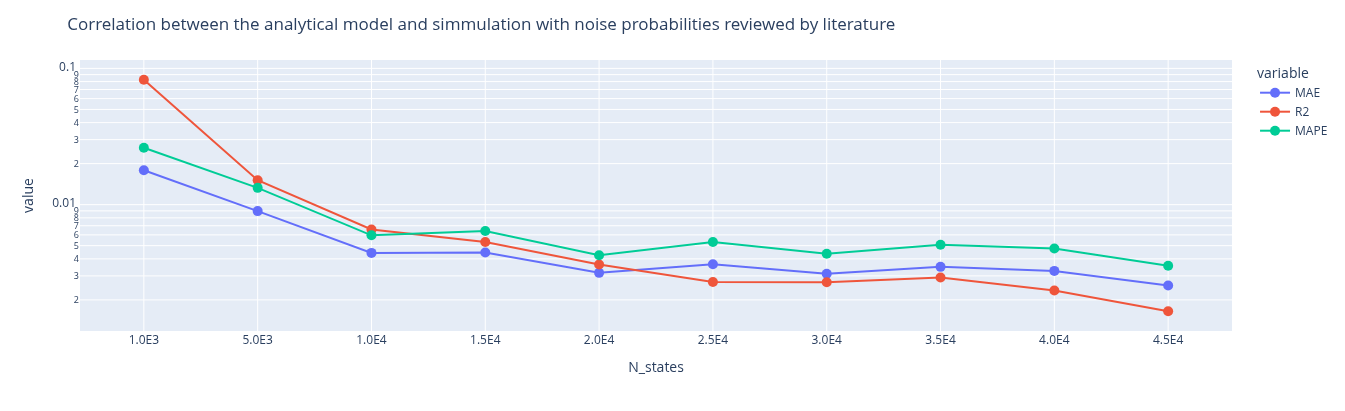

In [19]:
# Configuración del subplot
fig = px.line(df_reviewed,
                 y = ['MAE','R2','MAPE'],
                 x = 'N_states',
                 log_y=True,markers=True)
fig.update_traces(marker_size=10)
#fig.update_yaxes(range=[0.9,1])
#fig.update_yaxes(range=[0.9,1])
fig.update_layout(
    title = 'Correlation between the analytical model and simmulation with noise probabilities reviewed by literature',
    height = 411,
    width = 700
)

In [8]:
path = 'fixed error results/'


pure_filenames = ['pure_50x50_mesh_1E3_states_E91_data_2026_aer_simulator_25_02_2026_12_56_22',
                  'pure_50x50_mesh_5E3_states_E91_data_2026_aer_simulator_25_02_2026_14_33_00',
                  'pure_50x50_mesh_1E4_states_E91_data_2026_aer_simulator_25_02_2026_20_10_04',
                  'pure_50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_26_02_2026_15_59_56',
                  'pure_50x50_mesh_2E4_states_E91_data_2026_aer_simulator_25_02_2026_22_54_49']

error_filenames= ['50x50_mesh_1E3_states_E91_data_2026_aer_simulator_23_02_2026_18_32_14',
                  '50x50_mesh_5E3_states_E91_data_2026_aer_simulator_23_02_2026_14_22_55',
                  '50x50_mesh_1E4_estates_E91_data_2026_aer_simulator_23_02_2026_14_36_26',
                  '50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_23_02_2026_23_12_07',
                  '50x50_mesh_2E4_states_E91_data_2026_aer_simulator_24_02_2026_07_12_29',
                  '50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_24_02_2026_11_27_03']

test_filenames= ['10x10_mesh_1E3_E91_data_2026_aer_simulator_02_03_2026_15_36_28',
                 '10x10_mesh_1E4_states_E91_data_2026_aer_simulator_02_03_2026_16_23_52',
                 '10x10_mesh_1.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_08_36',
                 '10x10_mesh_2E4_states_E91_data_2026_aer_simulator_02_03_2026_19_41_56',
                 '10x10_mesh_2.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_04_56',
                 '10x10_3E4_states_E91_data_2026_aer_simulator_02_03_2026_15_54_44',
                 '10x10_mesh_3.5E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_08',
                 '10x10_mesh_4E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_51',]

In [9]:
N_data=20

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

experiment_number = 5
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

#"""

correlation_10_error = list()
correlation_50_error = list()
correlation_50_pure = list()

for experiment_name in test_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values    
    theta_FSS = np.linspace(0,2*pi,10)
    beta_angle = np.linspace(0,pi,10)
    model_10_error = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
    correlation_10_error.append( 1 - mae(y_true=model_10_error,y_pred=experiment) )
    
for experiment_name in error_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values
    theta_FSS = np.linspace(0,2*pi,50)
    beta_angle = np.linspace(0,pi,50)
    model_50_error = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
    correlation_50_error.append( 1 - mae(y_true=model_50_error,y_pred=experiment) )
    
for experiment_name in pure_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values
    theta_FSS = np.linspace(0,2*pi,50)
    beta_angle = np.linspace(0,pi,50)
    model_50_pure = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
    correlation_50_pure.append( 1 - mae(y_true=model_50_pure,y_pred=experiment) )


# Creación de los DataFrames
df_50_pure = pd.DataFrame( dict(zip(['Number of states per QKD transmission','correlation factor R2'],[[1E3,1E4,1.5E4,2E4,2.5E4],correlation_50_pure])) )
df_50_error = pd.DataFrame( dict(zip(['Number of states per QKD transmission','correlation factor R2'],[[1E3,5E3,1E4,1.5E4,2E4,2.5E4],correlation_50_error])) )
df_10_error = pd.DataFrame( dict(zip(['Number of states per QKD transmission','correlation factor R2'],[[1E3,1E4,1.5E4,2E4,2.5E4,3E4,3.5E4,4E4],correlation_10_error])) )


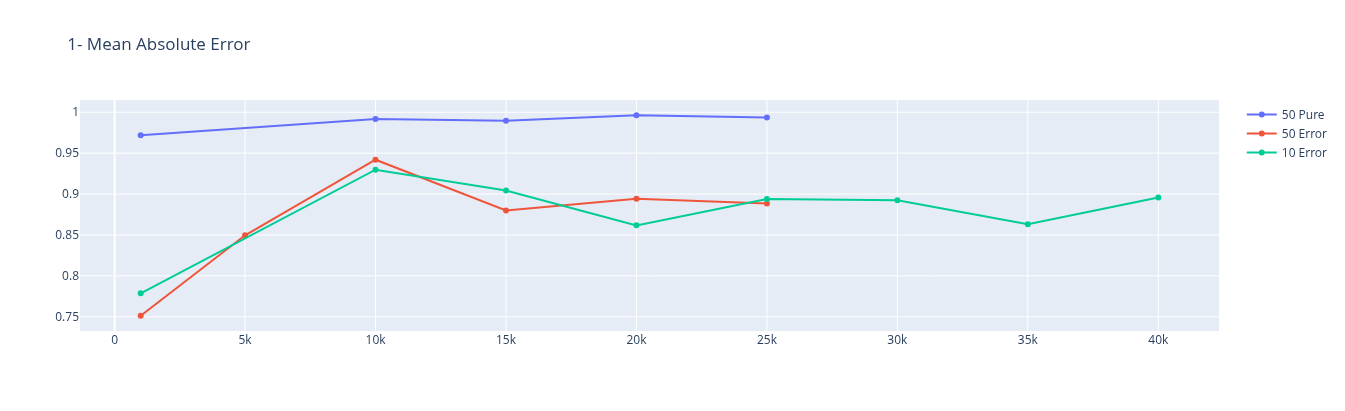

In [14]:
# Configuración del subplot
fig = make_subplots(
    rows=1, 
    cols=1, 
     # Actualizado para que coincida con tus datos
)

# Agregar la primera fila (row=1)
fig.add_trace(
    go.Scatter(
        x=df_50_pure['Number of states per QKD transmission'], 
        y=df_50_pure['correlation factor R2'], 
        mode='lines+markers', 
        name='50 Pure'
    ),
    row=1, col=1
)

# Agregar la segunda fila (row=2)
fig.add_trace(
    go.Scatter(
        x=df_50_error['Number of states per QKD transmission'], 
        y=df_50_error['correlation factor R2'], 
        mode='lines+markers', 
        name='50 Error'
    ),
    row=1, col=1
)

# Agregar la tercera fila (row=3)
fig.add_trace(
    go.Scatter(
        x=df_10_error['Number of states per QKD transmission'], 
        y=df_10_error['correlation factor R2'], 
        mode='lines+markers', 
        name='10 Error'
    ),
    row=1, col=1
)

# Ajuste estético (recomendado para 3 filas)
fig.update_layout(
    height=411,
    width=700,
    title_text="1- Mean Absolute Error"
)

fig.show()

R2 = -0.9672403657519384


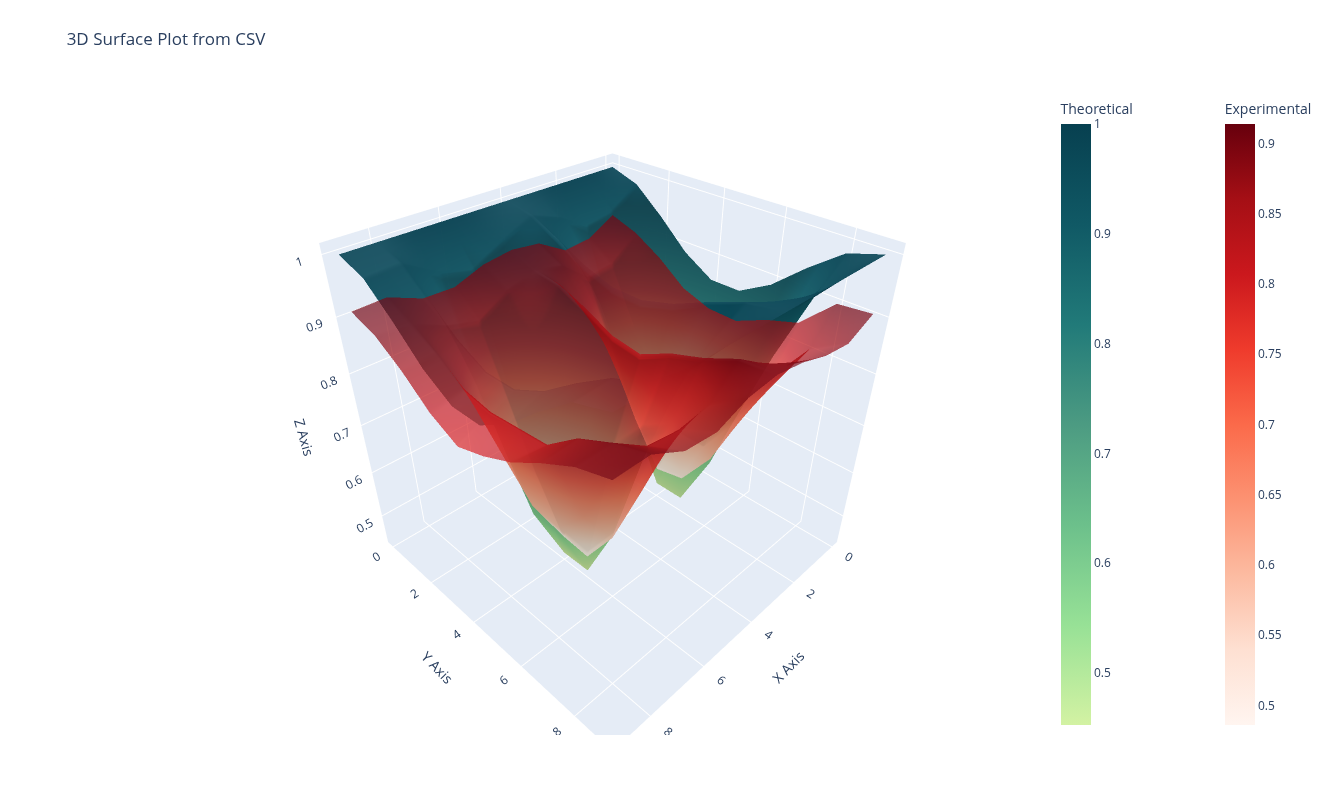

In [11]:
N_data=10

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

experiment_number = 1
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

experiment = pd.read_csv(path+test_filenames[experiment_number]+'.csv', header=None).dropna(axis=1,how='all').values
print (f"R2 = {r2(y_true=model,y_pred=experiment)}")
plot_surface_from_csv(model,experiment)

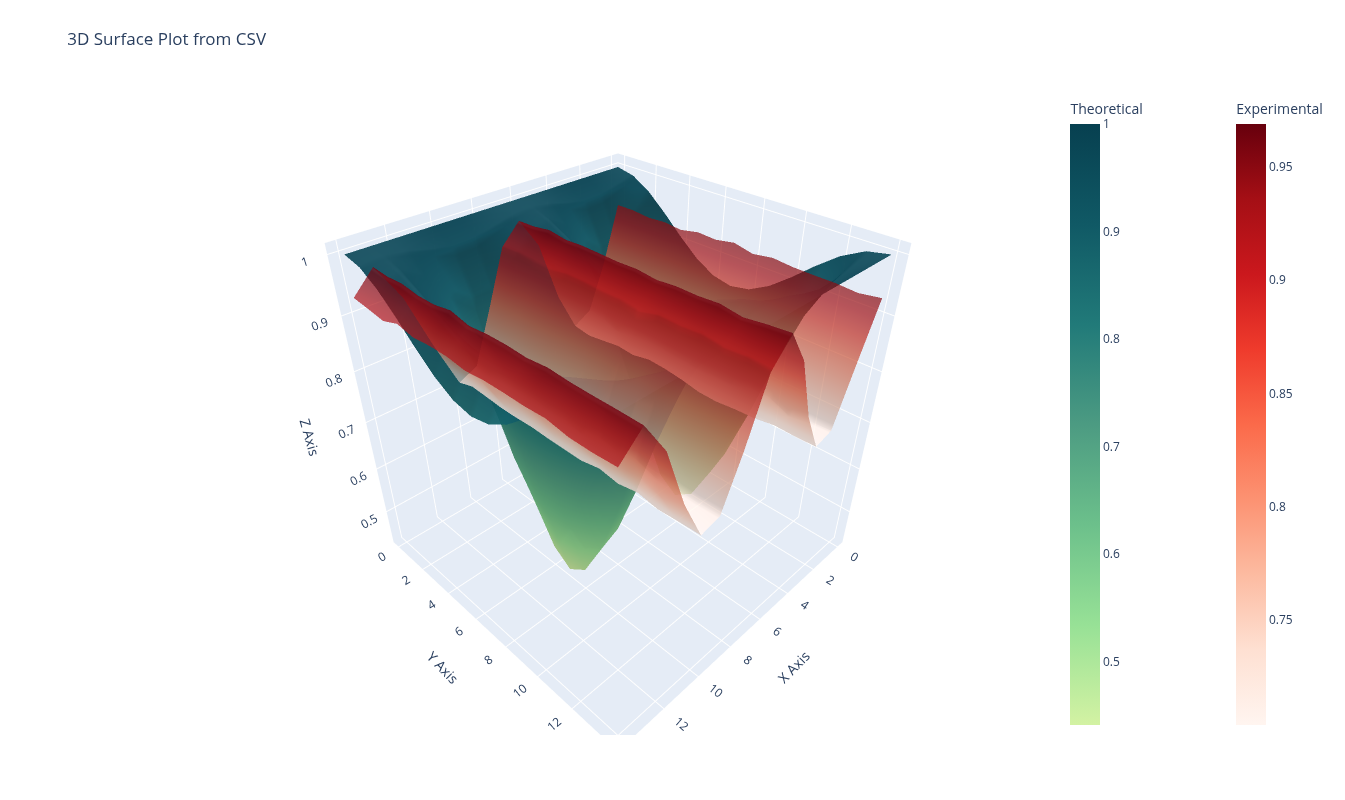

In [12]:

theta_FSS = np.linspace(0,2*pi,15)
beta_angle = np.linspace(0,pi,15)
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
experiment = pd.read_csv(path+'1_E91_data_2026_aer_simulator_03_03_2026_13_56_56'+'.csv', header=None).dropna(axis=1,how='all').values

plot_surface_from_csv(model,experiment)